# Import library

In [158]:
import bootstrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from  Common.ClassHandleData import dataReader as dr
BASE_DIR = Path.cwd().parent
endPoin = f"{BASE_DIR}/RawData/File_BTVN/"


# Yêu cầu 1 — Đọc & Làm sạch dữ liệu 


In [159]:
#Đọc dữ liệu
df_CuaHang = dr.load(endPoin + "data_CuaHangTienLoi_ShopKhai.xlsx","CuaHang")
df_HangHoa = dr.load(endPoin + "data_CuaHangTienLoi_ShopKhai.xlsx","HangHoa")
df_GiaoDich = dr.load(endPoin + "data_CuaHangTienLoi_ShopKhai.xlsx","GiaoDich")



Đã đọc XML
Đã đọc XML
Đã đọc XML


In [160]:
#Chuẩn hóa tên tỉnh/thành, tên quận/huyện (ví dụ: in hoa/thường, loại bỏ khoảng trắng thừa).
df_CuaHang["TinhThanh"] = (
    df_CuaHang["TinhThanh"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)

df_CuaHang["QuanHuyen"] = (
    df_CuaHang["QuanHuyen"]
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
    .str.title()
)
df_CuaHang

,MaCuaHang,TenCuaHang,TinhThanh,QuanHuyen,ViTri,DienTich_m2,SoNhanVien
0,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8
1,CH002,Shop K+ HCM CN2,Hcm,Bình Thạnh,Văn phòng,111,8
2,CH003,Shop K+ HCM CN3,Hcm,Phú Nhuận,Văn phòng,92,5
3,CH004,Shop K+ HCM CN4,Hcm,Bình Thạnh,Trường học,65,12
4,CH005,Shop K+ HCM CN5,Hcm,Quận 1,Trường học,86,11
5,CH006,Shop K+ Hà Nội CN6,Hà Nội,Cầu Giấy,Trung tâm thương mại,167,10
6,CH007,Shop K+ Hà Nội CN7,Hà Nội,Hà Đông,Trường học,123,7
7,CH008,Shop K+ Hà Nội CN8,Hà Nội,Hoàn Kiếm,Khu công nghiệp,124,7
8,CH009,Shop K+ Hà Nội CN9,Hà Nội,Cầu Giấy,Khu dân cư,128,10
9,CH010,Shop K+ Hà Nội CN10,Hà Nội,Hoàn Kiếm,Trường học,144,4


# Yêu cầu 2 — Gộp dữ liệu

In [161]:
#Kiểm tra null
df_all = pd.merge(df_CuaHang,df_GiaoDich,on="MaCuaHang")
df_all = pd.merge(df_all, df_HangHoa, on="MaHang")
df_all.isna().sum()
df_all

,MaCuaHang,TenCuaHang,TinhThanh,QuanHuyen,ViTri,DienTich_m2,SoNhanVien,MaGD,MaHang,SoLuong,Ngay,TenHang,DanhMuc,GiaBan,NhaCungCap
0,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00038,SP0046,43,2024-02-25,Snack Khoai Tây BBQ - Chai,Snack,53,Vinamilk
1,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00053,SP0002,5,2024-01-02,Coca Cola - Gói lớn,Đồ uống,45,Unilever
2,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00079,SP0063,1,2024-04-05,Snack Gà Cay - Hộp,Snack,38,PepsiCo
3,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00121,SP0005,38,2024-04-07,Coca Cola - Lon,Đồ uống,32,Unilever
4,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00134,SP0070,17,2024-01-21,Mì Hảo Hảo - Chai,Thực phẩm,30,PepsiCo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09898,SP0009,25,2024-02-11,Pepsi - Hộp,Đồ uống,35,Nestlé
9996,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09924,SP0064,56,2024-04-28,Snack Gà Cay - Chai,Snack,24,Nestlé
9997,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09937,SP0122,41,2024-01-22,Hạnh nhân mỹ - Gói lớn,Đồ khô,59,Unilever
9998,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09981,SP0060,34,2024-02-10,Bánh Que Vị Bơ - Túi,Snack,18,Orion


In [162]:
#Chuyển kiểu dữ liệu (Type Casting):
df_all["Ngay"] = pd.to_datetime(
    df_all["Ngay"],
    format="%Y-%m-%d"
)
df_all["GiaBan"] = df_all["GiaBan"].astype(int)
df_all["SoLuong"] = df_all["SoLuong"].astype(int)
df_all

,MaCuaHang,TenCuaHang,TinhThanh,QuanHuyen,ViTri,DienTich_m2,SoNhanVien,MaGD,MaHang,SoLuong,Ngay,TenHang,DanhMuc,GiaBan,NhaCungCap
0,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00038,SP0046,43,2024-02-25,Snack Khoai Tây BBQ - Chai,Snack,53,Vinamilk
1,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00053,SP0002,5,2024-01-02,Coca Cola - Gói lớn,Đồ uống,45,Unilever
2,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00079,SP0063,1,2024-04-05,Snack Gà Cay - Hộp,Snack,38,PepsiCo
3,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00121,SP0005,38,2024-04-07,Coca Cola - Lon,Đồ uống,32,Unilever
4,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00134,SP0070,17,2024-01-21,Mì Hảo Hảo - Chai,Thực phẩm,30,PepsiCo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09898,SP0009,25,2024-02-11,Pepsi - Hộp,Đồ uống,35,Nestlé
9996,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09924,SP0064,56,2024-04-28,Snack Gà Cay - Chai,Snack,24,Nestlé
9997,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09937,SP0122,41,2024-01-22,Hạnh nhân mỹ - Gói lớn,Đồ khô,59,Unilever
9998,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09981,SP0060,34,2024-02-10,Bánh Que Vị Bơ - Túi,Snack,18,Orion


# Yêu cầu 3 — Tính toán & Phân tích thống kê

In [163]:
#1. Tạo thêm các cột:
df_all['DoanhThu'] = df_all['SoLuong'] * df_all['GiaBan']
df_all["Thang"] = df_all["Ngay"].dt.month
df_all

,MaCuaHang,TenCuaHang,TinhThanh,QuanHuyen,ViTri,DienTich_m2,SoNhanVien,MaGD,MaHang,SoLuong,Ngay,TenHang,DanhMuc,GiaBan,NhaCungCap,DoanhThu,Thang
0,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00038,SP0046,43,2024-02-25,Snack Khoai Tây BBQ - Chai,Snack,53,Vinamilk,2279,2
1,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00053,SP0002,5,2024-01-02,Coca Cola - Gói lớn,Đồ uống,45,Unilever,225,1
2,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00079,SP0063,1,2024-04-05,Snack Gà Cay - Hộp,Snack,38,PepsiCo,38,4
3,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00121,SP0005,38,2024-04-07,Coca Cola - Lon,Đồ uống,32,Unilever,1216,4
4,CH001,Shop K+ HCM CN1,Hcm,Quận 3,Trung tâm thương mại,70,8,GD00134,SP0070,17,2024-01-21,Mì Hảo Hảo - Chai,Thực phẩm,30,PepsiCo,510,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09898,SP0009,25,2024-02-11,Pepsi - Hộp,Đồ uống,35,Nestlé,875,2
9996,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09924,SP0064,56,2024-04-28,Snack Gà Cay - Chai,Snack,24,Nestlé,1344,4
9997,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09937,SP0122,41,2024-01-22,Hạnh nhân mỹ - Gói lớn,Đồ khô,59,Unilever,2419,1
9998,CH020,Shop K+ Cần Thơ CN20,Cần Thơ,Ninh Kiều,Trường học,117,11,GD09981,SP0060,34,2024-02-10,Bánh Que Vị Bơ - Túi,Snack,18,Orion,612,2


In [164]:
#2. Phân tích tổng quan:
#Tổng doanh thu toàn hệ thống
tong_doanh_thu = df_all["DoanhThu"].sum()
print(f"{tong_doanh_thu:,}")

10,887,732


In [165]:
#Doanh thu theo từng cửa hàng
df_cua_hang = (
    df_all
    .groupby(["MaCuaHang", "TenCuaHang"])[["DoanhThu","SoLuong"]]
    .sum()
    .reset_index()
)

df_cua_hang

,MaCuaHang,TenCuaHang,DoanhThu,SoLuong
0,CH001,Shop K+ HCM CN1,523302,14640
1,CH002,Shop K+ HCM CN2,486532,13352
2,CH003,Shop K+ HCM CN3,578165,15858
3,CH004,Shop K+ HCM CN4,565084,15903
4,CH005,Shop K+ HCM CN5,509127,14273
5,CH006,Shop K+ Hà Nội CN6,550121,16030
6,CH007,Shop K+ Hà Nội CN7,493936,13949
7,CH008,Shop K+ Hà Nội CN8,613951,17450
8,CH009,Shop K+ Hà Nội CN9,511904,14178
9,CH010,Shop K+ Hà Nội CN10,551079,15838


In [166]:
#Doanh thu theo từng tỉnh/thành
doanh_thu_tinh_thanh = (
    df_all
    .groupby(["TinhThanh"])["DoanhThu"]
    .sum()
    .reset_index()
)

doanh_thu_tinh_thanh

,TinhThanh,DoanhThu
0,Cần Thơ,2783305
1,Hcm,2662210
2,Hà Nội,2720991
3,Đà Nẵng,2721226


In [167]:
#Doanh thu theo danh mục sản phẩm
doanh_thu_DM_SP = (
    df_all
    .groupby(["DanhMuc"])["DoanhThu"]
    .sum()
    .reset_index()
)

doanh_thu_DM_SP

,DanhMuc,DoanhThu
0,Gia dụng,1386644
1,Snack,2087692
2,Thực phẩm,1987563
3,Đồ khô,1649950
4,Đồ uống,3775883


In [168]:
#3. Sản phẩm & Cửa hàng:
df_san_pham = (
    df_all
    .groupby(["MaHang", "TenHang"])[["SoLuong", "DoanhThu"]]
    .sum()
    .reset_index()
)
#Top 10 sản phẩm bán chạy nhất (theo SoLuong)
result = (
    df_san_pham
    .sort_values(by="SoLuong",ascending=False)
    .head(10)
)
result

,MaHang,TenHang,SoLuong,DoanhThu
122,SP0123,Hạnh nhân mỹ - Hộp,3041,161173
41,SP0042,Red Bull - Túi,3038,145824
116,SP0117,Đậu phộng tỏi ớt - Hộp,3034,91020
39,SP0040,Red Bull - Chai,2972,178320
8,SP0009,Pepsi - Hộp,2964,103740
111,SP0112,Hạt điều rang muối - Chai,2964,100776
4,SP0005,Coca Cola - Lon,2943,94176
60,SP0061,Snack Gà Cay - Gói nhỏ,2936,149736
66,SP0067,Mì Hảo Hảo - Gói nhỏ,2869,37297
89,SP0090,Cơm nắm Rong biển - Túi,2820,45120


In [169]:
#Top 10 sản phẩm có doanh thu cao nhất
top_doanh_thu_SP = (
    df_san_pham
    .sort_values(by="DoanhThu",ascending=False)
    .head(10)
)
top_doanh_thu_SP

,MaHang,TenHang,SoLuong,DoanhThu
39,SP0040,Red Bull - Chai,2972,178320
122,SP0123,Hạnh nhân mỹ - Hộp,3041,161173
96,SP0097,Nước rửa tay Lifebuoy - Gói nhỏ,2724,160716
60,SP0061,Snack Gà Cay - Gói nhỏ,2936,149736
16,SP0017,7Up - Lon,2448,146880
117,SP0118,Đậu phộng tỏi ớt - Chai,2620,146720
41,SP0042,Red Bull - Túi,3038,145824
52,SP0053,Snack Rong Biển - Lon,2578,144368
119,SP0120,Đậu phộng tỏi ớt - Túi,2360,139240
20,SP0021,Twister Cam - Hộp,2479,138824


In [170]:
#Top 5 cửa hàng doanh thu cao nhất
top_doanh_thu_cua_hang = (
    df_cua_hang
    .sort_values(by="DoanhThu",ascending=False)
    .head(5)
)
top_doanh_thu_cua_hang

,MaCuaHang,TenCuaHang,DoanhThu,SoLuong
7,CH008,Shop K+ Hà Nội CN8,613951,17450
14,CH015,Shop K+ Đà Nẵng CN15,603527,16784
11,CH012,Shop K+ Đà Nẵng CN12,584732,15937
2,CH003,Shop K+ HCM CN3,578165,15858
17,CH018,Shop K+ Cần Thơ CN18,573197,16075


In [171]:
#Top 5 cửa hàng có lượng bán thấp nhất (theo SoLuong)
Bottom_cua_hang_SL = (
    df_cua_hang
    .sort_values(by="SoLuong")
    .head(5)
)
Bottom_cua_hang_SL

,MaCuaHang,TenCuaHang,DoanhThu,SoLuong
12,CH013,Shop K+ Đà Nẵng CN13,465934,13134
1,CH002,Shop K+ HCM CN2,486532,13352
6,CH007,Shop K+ Hà Nội CN7,493936,13949
8,CH009,Shop K+ Hà Nội CN9,511904,14178
4,CH005,Shop K+ HCM CN5,509127,14273


<Axes: xlabel='ViTri'>

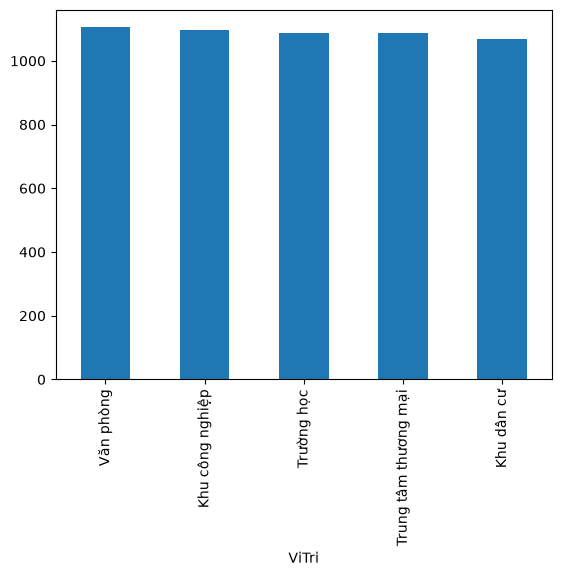

In [186]:
#4. Phân tích theo vị trí cửa hàng:
#So sánh doanh thu TB của các loại vị trí: Khu dân cư, Văn phòng, Trường học, Khu công nghiệp, Trung tâm thương mại.
doanh_thu_tb = (
    df_all
    .groupby("ViTri", as_index=False)["DoanhThu"]
    .mean()
    .rename(columns={"DoanhThu": "DoanhThuTB"})
    .sort_values(by="DoanhThuTB", ascending=False)
)
doanh_thu_tb.plot(
    x="ViTri",
    y="DoanhThuTB",
    kind="bar",
    legend=False
)


In [173]:
for _, row in doanh_thu_tb.iterrows():
    print(f"{'█' * int(row['DoanhThuTB'] / 50)} {row['DoanhThuTB']:.0f} {row['ViTri']} ")

██████████████████████ 1105 Văn phòng 
█████████████████████ 1096 Khu công nghiệp 
█████████████████████ 1088 Trường học 
█████████████████████ 1087 Trung tâm thương mại 
█████████████████████ 1070 Khu dân cư 


In [174]:
#Xác định loại vị trí có: Doanh thu trung bình cao nhất, Số giao dịch nhiều nhất.
vi_tri_thong_ke = (
    df_all
    .groupby("ViTri", as_index=False)
    .agg(
        DoanhThuTB=("DoanhThu", "mean"),
        SoGiaoDich=("MaGD", "nunique")  
    )
)

vi_tri_thong_ke.nlargest(1, "DoanhThuTB")

,ViTri,DoanhThuTB,SoGiaoDich
4,Văn phòng,1104.882413,1973


# Yêu cầu 4 — Phân tích nâng cao & Trực quan hóa (Phần không bắt buộc)

In [ ]:
#1. Phân tích xu hướng doanh thu từng tháng
doanh_thu_thang = (
    df_all
    .groupby(by="Thang", as_index=False)["DoanhThu"]
    .sum()
    .sort_values("Thang")
)
doanh_thu_thang

,Thang,DoanhThu
0,1,2871221
1,2,2501932
2,3,2734933
3,4,2779646


In [ ]:
#Xác định Top 5 sản phẩm bán chạy theo từng thành phố.
top5_san_pham = (
    df_all
    .groupby(["TinhThanh", "MaHang", "TenHang"], as_index=False)["SoLuong"]
    .sum()
    .sort_values(
        by=["TinhThanh", "SoLuong"],
        ascending=[True, False] # => tinh_thanh tăng từ A -> Z && SoLuong giảm dần
    )
    .head(5)
)

top5_san_pham

,TinhThanh,MaHang,TenHang,SoLuong
43,Cần Thơ,SP0044,Snack Khoai Tây BBQ - Gói lớn,970
11,Cần Thơ,SP0012,Pepsi - Túi,887
60,Cần Thơ,SP0061,Snack Gà Cay - Gói nhỏ,887
103,Cần Thơ,SP0104,Nước lau nhà Sunlight - Gói lớn,858
112,Cần Thơ,SP0113,Hạt điều rang muối - Lon,842


In [181]:
#Xác định Top 3 nhà cung cấp mang lại doanh thu lớn nhất.
top3_nha_cung_cap = (
    df_all
    .groupby("NhaCungCap", as_index=False)["DoanhThu"]
    .sum()
    .sort_values("DoanhThu", ascending=False)
    .head(3)
)

top3_nha_cung_cap

,NhaCungCap,DoanhThu
6,Unilever,2009445
5,PepsiCo,1656618
3,Orion,1434655


In [ ]:
#Tìm sản phẩm bán rất chậm (Low-selling): Liệt kê Top 5 sản phẩm có tổng số lượng bán ra thấp nhất.
low_selling = (
    df_all
    .groupby(["MaHang", "TenHang"], as_index=False)["SoLuong"]
    .sum()
    .nsmallest(5, "SoLuong")
)

low_selling

<Axes: title={'center': 'Doanh thu theo tháng'}, xlabel='Thang'>

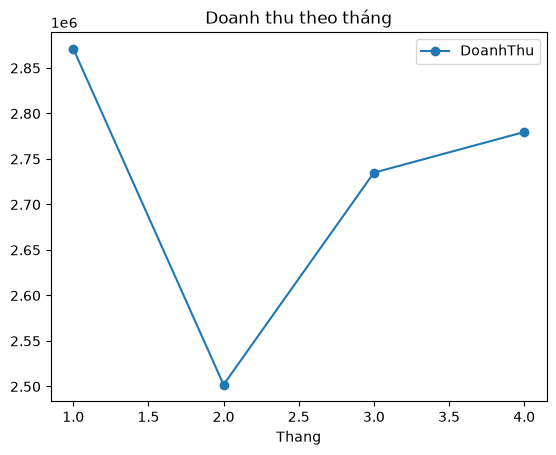

In [182]:
#5. Vẽ biểu đồ trực quan hóa
#5.1. Doanh thu theo tháng
doanh_thu_thang.plot(
    x="Thang",
    y="DoanhThu",
    kind="line",
    marker="o",
    title="Doanh thu theo tháng"
)

<Axes: title={'center': 'Top 10 mặt hàng doanh thu cao nhất'}, xlabel='TenHang'>

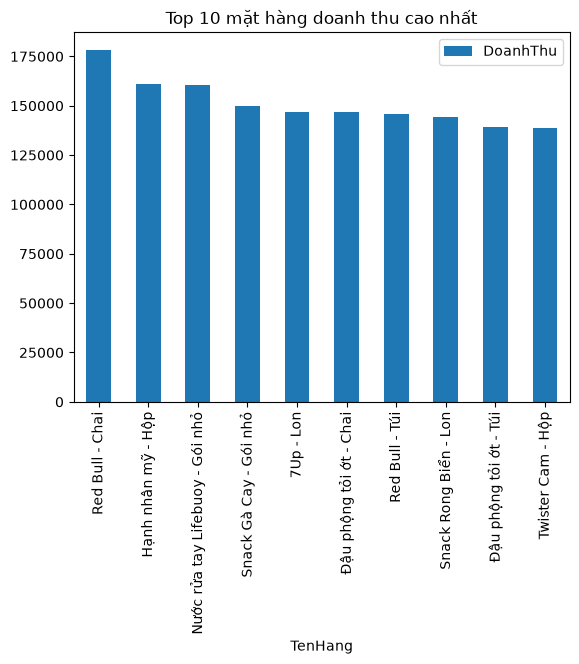

In [183]:
#5.2. Top 10 mặt hàng doanh thu cao nhất
top_doanh_thu_SP.plot(
    x="TenHang",
    y="DoanhThu",
    kind="bar",
    title="Top 10 mặt hàng doanh thu cao nhất"
)

<Axes: title={'center': 'Doanh thu trung bình theo vị trí'}, xlabel='ViTri'>

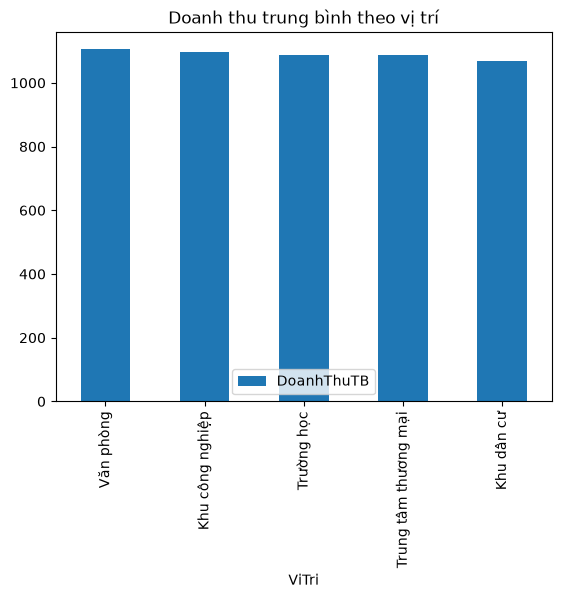

In [184]:
#5.3. Doanh thu TB theo vị trí
doanh_thu_tb.plot(
    x="ViTri",
    y="DoanhThuTB",
    kind="bar",
    title="Doanh thu trung bình theo vị trí"
)